## Deconvolution using geneformer (pseudobulk + single-cell reference)
This tutorial demonstrates how to use DECONVersation to run and evaluate deconvolution on pseudobulk data, using built-in pseudobulk simulation functions available within the package. Cell2Sentence embeddings are used throughout, though the workflow is fully adaptable to Geneformer or CellHermes. The tutorial covers the full pipeline: generating pseudobulk data, extracting Cell2Sentence embeddings from both the pseudobulk and single-cell reference datasets, constructing signature matrices, and estimating cell type proportions via NNLS. Predicted proportions are then evaluated against ground truth using RMSE and Pearson correlation to benchmark deconvolution performance. <br>
<b> Requires: </b> Annotated single-cell data (cell type or lineage level) with <b> raw counts </b>

### Step 0: Load reference data (scRNA-seq)

In [1]:
# Append path to deconversation modules
import sys
import os
import scanpy as sc
sys.path.append('../deconversation')

In [2]:
# Import associated modules
from pseudobulk import *
from preprocessing import *

In [3]:
# Path to single-cell RNAseq data 

# Contains two samples that are essentially duplicates (pre-menopausal) - no batch effects
path_1 = "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/"

# Contains single cell data from a single sample with batch effects (post-menopausal)
path_2 = "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/single_cell_refs/CZI041N_pre_menopausal.h5ad"

In [ ]:
# Load scRNA data
adata_1 = sc.read_h5ad(path_1) #Pre Menopausal batch

### Step 1: Prep data for Cell2Sentence

In [21]:
# Read the h5ad file (just to explore columns and variables)
adata = sc.read_h5ad(path)

adata = adata[adata.obs["broad_type"].isin(
    ['B cells', 'Monocytes', 'NK cells', 'T cells', 'mDC', 'pDC']
)]

# Remove unmapped genes
adata = adata[:, adata.var.index.notnull()]

# Prep data for geneformer
adata = load_and_prep_data(adata= adata, cell_type_col= "broad_type", mode="geneformer")

/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv/tutorials/../deconversation/preprocessing.py:50: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["cell_id"] = adata.obs.index


### Step 2: Load bulk data

In [39]:
# Read in bulk RNAseq data
hoek_bulk = pd.read_csv("/gpfs/commons/groups/compbio/projects/rf_projects/deconv_data/deconvBench/bulk/hoek/hoek_counts.csv",
                       index_col=0)

# Map genes to ensembl id (required for geneformer)
hoek_bulk.index = gene_id_name_map(gene_list=hoek_bulk.index, mode="to_ensembl" )

# Drop unmapped genes 
hoek_bulk = hoek_bulk.loc[hoek_bulk.index.dropna()]

### Step 3: Create signature matrix

In [41]:
sig_mat_gf = create_signature_matrix(adata = adata,
                                     sample_col = "batch", # sample id column
                                     celltype_col = "broad_type",
                                     groupby = "broad_type",
                                     output_path = None)

/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv/tutorials/../deconversation/preprocessing.py:239: UserWarning: Expression matrix contains non-integer values. Raw counts are expected. 
  warnings.warn(
/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv/tutorials/../deconversation/preprocessing.py:251: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  signature = expr.groupby(groupby).mean().T


### Step 4: Extract Geneformer Embeddings

In [42]:
from embeddings import *

geneformer successfully imported.
cell2sentence is not installed. Skipping related functions.


In [ ]:
# Extract geneformer embeddings for signature matrix
sig_mat_gf_embed = extract_embs(
    bulk_df = sig_mat_gf.T,
    mode = "geneformer",
    temp_output_dir = "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/", 
    model_path= "ctheodoris/Geneformer",
    delete_temp_files = True
)

In [ ]:
# Extract geneformer embeddings for signature matrix
gf_embed = extract_embs(
    bulk_df = hoek_bulk.T,
    mode = "geneformer",
    temp_output_dir = "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/", 
    model_path= "ctheodoris/Geneformer",
    delete_temp_files = True
)

### Step 5: Run Non-Negative Least Squares (NNLS)

In [47]:
from deconvolution import *

In [46]:
# Load previously saved embeddings
sig_mat_gf = pd.read_csv("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/hoek/gf_sig_matrix_embed_hoek.csv", index_col=0)
bulk_gf = pd.read_csv("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/hoek/gf_bulk_embed_hoek.csv", index_col=0)

# Load ground truth 
ground_truth = pd.read_csv("/gpfs/commons/groups/compbio/projects/rf_projects/deconv_data/deconvBench/bulk/hoek/hoek_facs.csv",
                          index_col=0)

In [55]:
# Run NNLS
cell_prop_pred = run_deconv_nnls(bulk_df = bulk_gf.T,
                                 signature_df = sig_mat_gf.T,
                                 normalize = True)

Using 1152 common features.
Running NNLS deconvolution...


### Step 7: Evaluate estimated proportions

In [52]:
from evaluation import *

In [56]:
# Merge mDC and pDC to match ground truth
cell_prop_pred["mDC"] = cell_prop_pred["pDC"] + cell_prop_pred["mDC"]

# Drop pDC after merging with mDC
cell_prop_pred = cell_prop_pred.drop(columns=["pDC"])

# rename T cells to match 
cell_prop_pred = cell_prop_pred.rename(columns={"T cells" : "T cell"})

In [58]:
#Compute RMSE per cell type
rmse_per_cell_type = compute_rmse(true_df = ground_truth.T,
                                 pred_df = cell_prop_pred,
                                 return_per_celltype = True)

rmse_per_cell_type = pd.DataFrame(rmse_per_cell_type)

rmse_per_cell_type

,overall,per_celltype
T cell,0.167694,0.296048
Monocytes,0.167694,0.201940
B cells,0.167694,0.071004
mDC,0.167694,0.013942
NK cells,0.167694,0.083349


/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv/tutorials/../deconversation/evaluation.py:300: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = pearsonr(x, y)


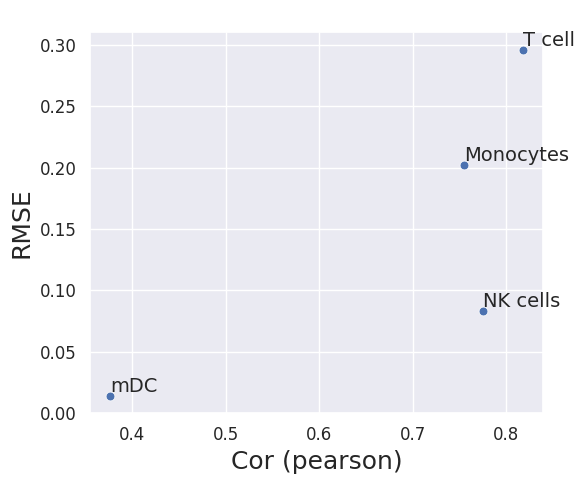

In [64]:
# Visualize
plot_rmse_vs_corr_by_celltype(
    true_df = ground_truth.T,
    pred_df = cell_prop_pred
)